# AusLAMP Victoria: QA/QC and Site Analysis

**Goal**: Comprehensive quality control and visualization of all 100 MT sites.

**Analysis includes**:
1. Load metadata for all sites
2. Site location maps (EDL vs LEMI-424)
3. Recording timelines for remote reference selection
4. Statistical analysis (first hour of each site)
5. AGRF25 model comparison
6. Data quality flags and recommendations

**Data**: 81 EDL sites (2014) + 19 LEMI-424 sites (2016-2017)

In [1]:
import sys
sys.path.insert(0, '../src')

from readers import read_station, get_all_metadata
from config import DataPaths
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Display options
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

def caption(text):
    """Display a figure caption as wrapped, italic markdown."""
    from IPython.display import Markdown, display
    display(Markdown(f"*{text}*"))

## 1. Load Metadata for All Sites

In [2]:
# Load from CSV (already generated)
metadata_file = DataPaths.PROCESSED_DATA_DIR / 'metadata_all_sites.csv'
df_meta = pd.read_csv(metadata_file)

# Parse datetime columns (format='mixed' handles inconsistent timezone formats)
df_meta['start_time'] = pd.to_datetime(df_meta['start_time'], format='mixed')
df_meta['end_time'] = pd.to_datetime(df_meta['end_time'], format='mixed')

print(f"Loaded metadata for {len(df_meta)} sites")
print(f"  EDL: {len(df_meta[df_meta['instrument']=='EDL'])}")
print(f"  LEMI-424: {len(df_meta[df_meta['instrument']=='LEMI-424'])}")

df_meta.head(10)

Loaded metadata for 100 sites
  EDL: 81
  LEMI-424: 19


,station_id,latitude,longitude,elevation,declination,declination_model,comments,channels_recorded,start_time,end_time,sample_rate,n_runs,instrument,mth5_file,duration_days
0,VIC001,-38.92,146.44,90.00,12.45,AGRF,Ex and Ey dipoles deployed in S-N and W-E dire...,"['bx', 'by', 'bz', 'ex', 'ey']",2014-04-11 06:00:00+00:00,2014-05-08 00:59:59.900000+00:00,10.00,1,EDL,E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_MTH5\V...,26.79
1,VIC002,-38.34,142.47,33.00,10.58,AGRF,NaN,"['bx', 'by', 'bz', 'ex', 'ey']",2014-05-13 00:00:00+00:00,2014-06-06 03:59:59.900000+00:00,10.00,1,EDL,E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_MTH5\V...,24.17
2,VIC003,-38.52,142.97,50.00,10.85,AGRF,NaN,"['bx', 'by', 'bz', 'ex', 'ey']",2014-05-12 03:00:00+00:00,2014-06-06 22:59:59.900000+00:00,10.00,5,EDL,E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_MTH5\V...,25.83
3,VIC004R,-38.53,143.49,100.80,11.09,AGRF,NaN,"['bx', 'by', 'bz', 'ex', 'ey', 'temperature_e'...",2017-12-14 03:20:00+00:00,2018-01-19 22:06:37+00:00,1.00,1,LEMI-424,E:\MT_Timeseries_DATA\MT_AusLAMP_GA\LEMI_MTH5\...,36.78
4,VIC005,-38.51,143.99,184.00,11.45,AGRF,NaN,"['bx', 'by', 'bz', 'ex', 'ey']",2014-05-11 00:00:00+00:00,2014-05-28 22:59:59.900000+00:00,10.00,1,EDL,E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_MTH5\V...,17.96
5,VIC006,-38.45,145.00,120.00,11.75,AGRF,NaN,"['bx', 'by', 'bz', 'ex', 'ey']",2014-04-06 07:00:00+00:00,2014-05-08 21:59:59.900000+00:00,10.00,1,EDL,E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_MTH5\V...,32.62
6,VIC007,-38.50,145.51,NaN,12.00,AGRF,NaN,"['bx', 'by', 'bz', 'ex', 'ey']",2014-05-08 08:00:00+00:00,2014-05-26 17:59:59.900000+00:00,10.00,1,EDL,E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_MTH5\V...,18.42
7,VIC008,-38.50,146.00,46.00,12.22,AGRF,NaN,"['bx', 'by', 'bz', 'ex', 'ey']",2014-04-09 02:00:00+00:00,2014-05-07 21:59:59.900000+00:00,10.00,1,EDL,E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_MTH5\V...,28.83
8,VIC009R,-38.51,146.52,309.30,12.50,AGRF,NaN,"['bx', 'by', 'bz', 'ex', 'ey', 'temperature_e'...",2017-12-18 00:00:00+00:00,2018-01-19 22:30:32+00:00,1.00,1,LEMI-424,E:\MT_Timeseries_DATA\MT_AusLAMP_GA\LEMI_MTH5\...,32.94
9,VIC010,-38.47,147.03,3.00,12.46,AGRF,NaN,"['bx', 'by', 'bz', 'ex', 'ey']",2014-04-11 05:00:00+00:00,2014-05-07 01:59:59.900000+00:00,10.00,1,EDL,E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_MTH5\V...,25.87


In [3]:
# Summary statistics
print("\nRecording Duration by Instrument:")
print(df_meta.groupby('instrument')['duration_days'].describe())

print("\nDate Range:")
print(f"  Earliest: {df_meta['start_time'].min()}")
print(f"  Latest: {df_meta['end_time'].max()}")

print("\nSample Rates:")
print(df_meta.groupby('instrument')['sample_rate'].value_counts())


Recording Duration by Instrument:
            count  mean   std   min   25%   50%   75%    max
instrument                                                  
EDL         81.00 25.68 11.09  9.29 16.92 22.12 32.82  56.53
LEMI-424    19.00 55.40 48.60 32.74 35.34 37.75 39.43 209.97

Date Range:
  Earliest: 2013-11-19 08:00:00+00:00
  Latest: 2018-01-21 20:42:04+00:00

Sample Rates:
instrument  sample_rate
EDL         10.00          81
LEMI-424    1.00           19
Name: count, dtype: int64


## 2. Site Location Map

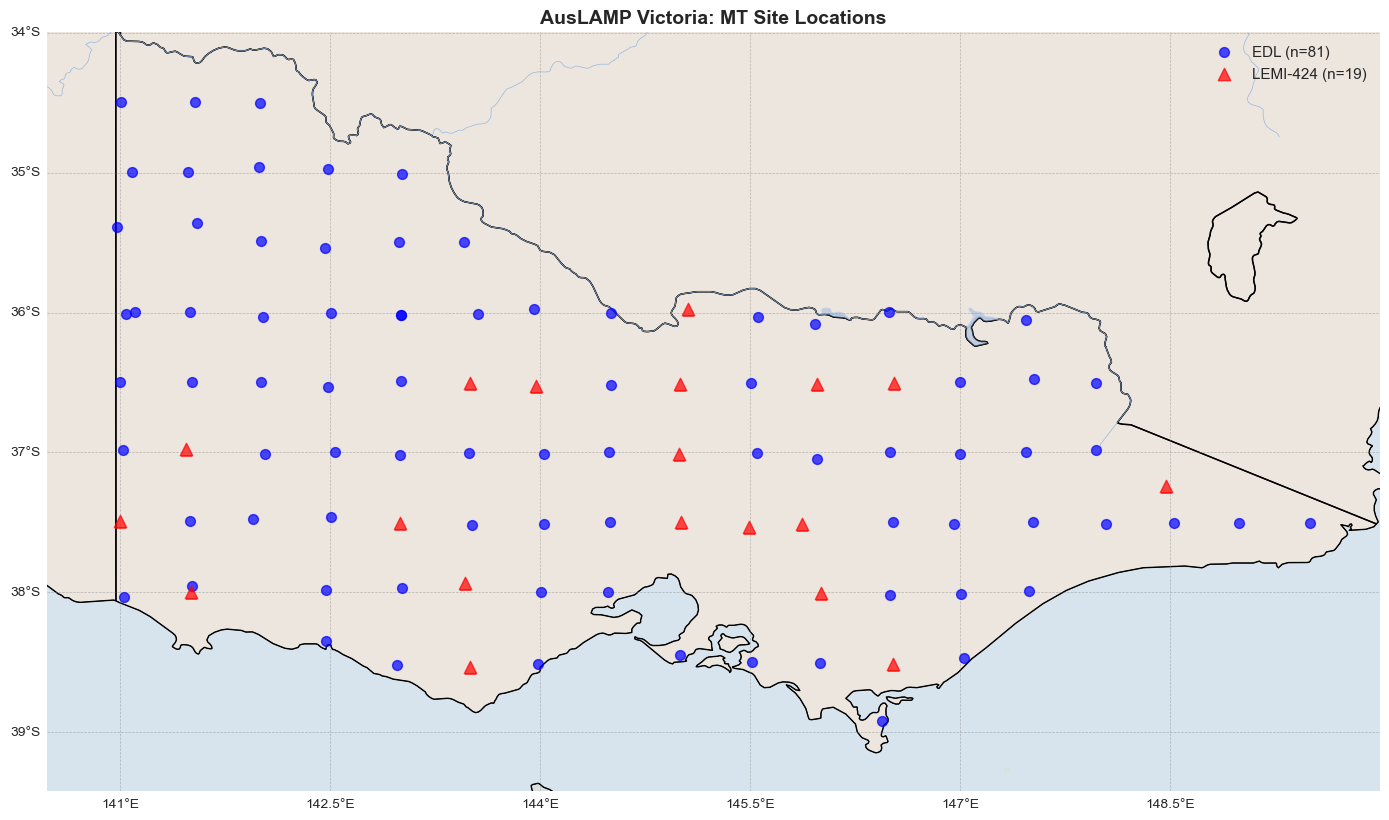

*Figure 1. Map showing 100 MT sites across Victoria. Blue circles: EDL sites (n=81, 2014). Red triangles: LEMI-424 sites (n=19, 2016-2017).*

In [4]:
# Create map with Cartopy
fig = plt.figure(figsize=(14, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set extent to Victoria
lat_min = df_meta['latitude'].min() - 0.5
lat_max = df_meta['latitude'].max() + 0.5
lon_min = df_meta['longitude'].min() - 0.5
lon_max = df_meta['longitude'].max() + 0.5
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Add features
ax.add_feature(cfeature.LAND, facecolor='wheat', alpha=0.3)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=1.0)
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.RIVERS, linewidth=0.5)

# Plot EDL sites
edl_sites = df_meta[df_meta['instrument'] == 'EDL']
ax.scatter(edl_sites['longitude'], edl_sites['latitude'],
           c='blue', marker='o', s=50, alpha=0.7, 
           label=f'EDL (n={len(edl_sites)})',
           transform=ccrs.PlateCarree(), zorder=5)

# Plot LEMI-424 sites
lemi_sites = df_meta[df_meta['instrument'] == 'LEMI-424']
ax.scatter(lemi_sites['longitude'], lemi_sites['latitude'],
           c='red', marker='^', s=80, alpha=0.7,
           label=f'LEMI-424 (n={len(lemi_sites)})',
           transform=ccrs.PlateCarree(), zorder=5)

# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax.legend(loc='upper right', fontsize=11)
ax.set_title('AusLAMP Victoria: MT Site Locations', fontsize=14, fontweight='bold')

plt.tight_layout()

# Save figure
fig.savefig(DataPaths.FIGURES_DIR / 'site_locations_map.png', dpi=300, bbox_inches='tight')
plt.show()

caption(f"Figure 1. Map showing {len(df_meta)} MT sites across Victoria. "
        f"Blue circles: EDL sites (n={len(edl_sites)}, 2014). "
        f"Red triangles: LEMI-424 sites (n={len(lemi_sites)}, 2016-2017).")

## 3. Recording Timelines for Remote Reference Selection

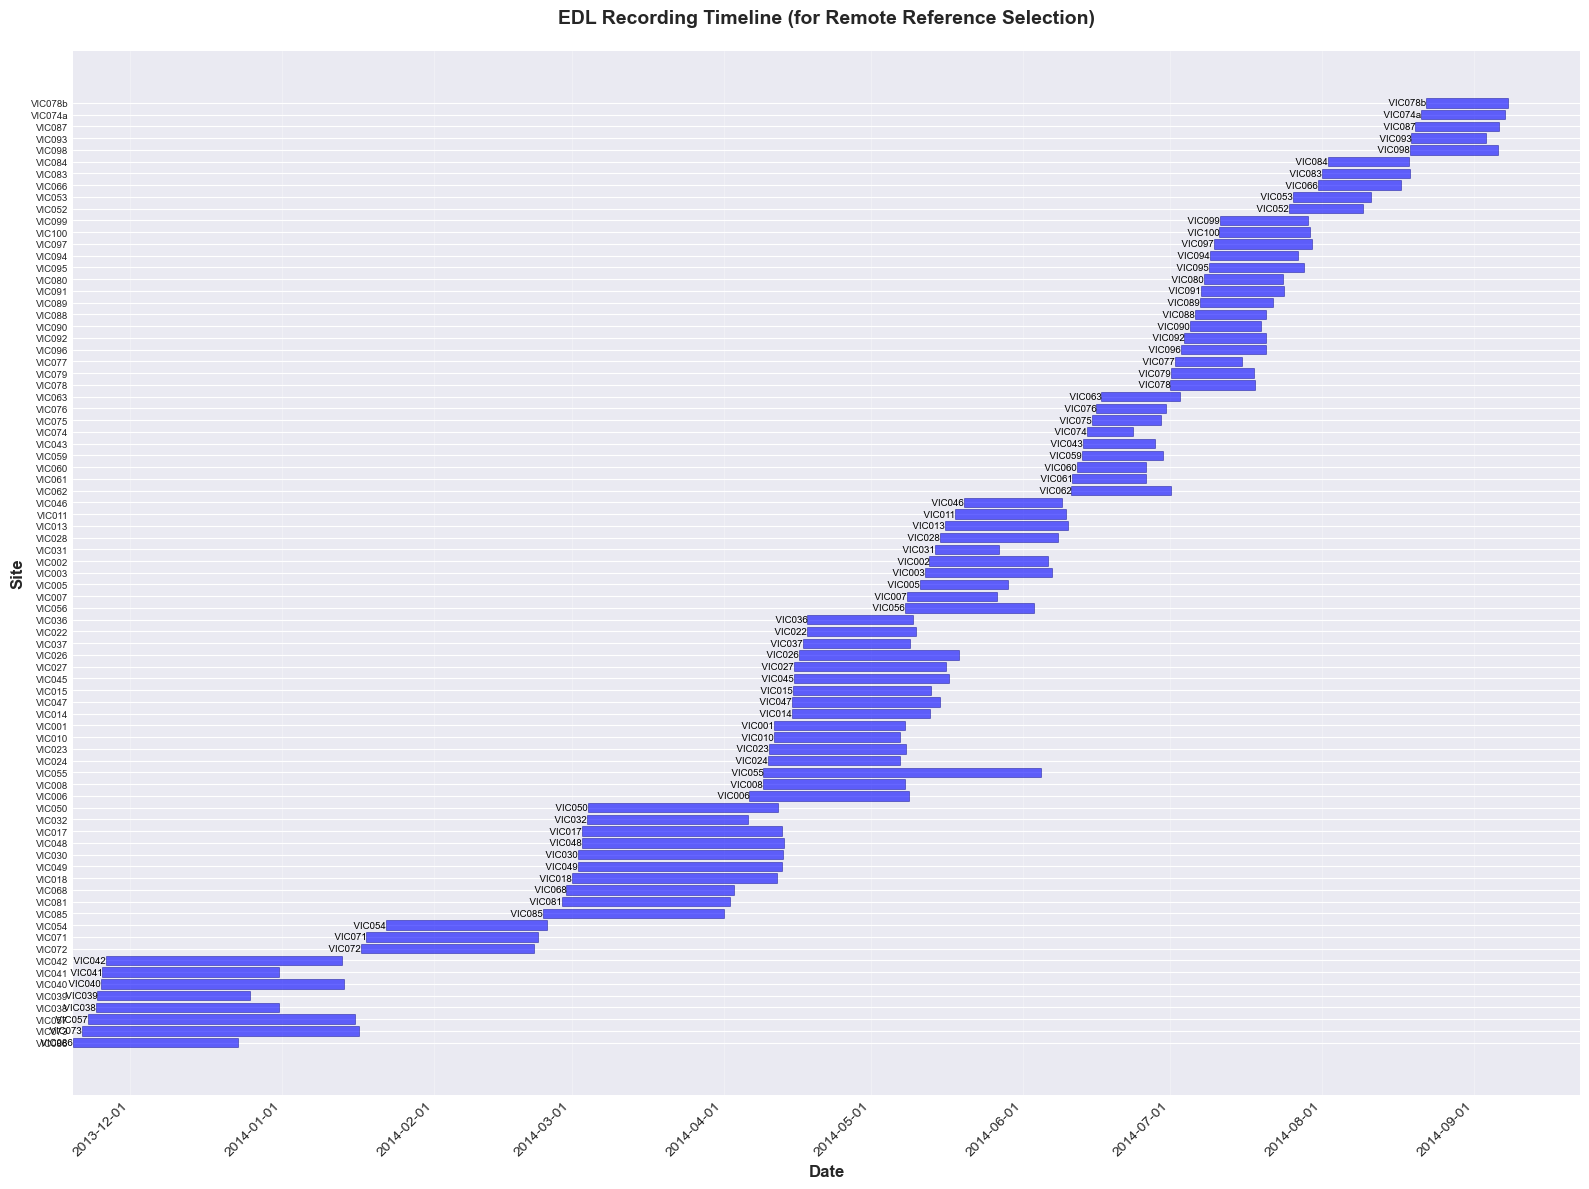

*Figure 2. EDL recording timeline showing 81 sites sorted by start date. Horizontal bars represent recording periods. Overlapping recordings can be used as remote references for magnetotelluric processing.*

In [5]:
# EDL Recording Timeline
edl_data = df_meta[df_meta['instrument'] == 'EDL'].copy()
edl_data = edl_data.sort_values('start_time')

fig, ax = plt.subplots(figsize=(16, 12))

for idx, (_, row) in enumerate(edl_data.iterrows()):
    ax.barh(idx, 
            (row['end_time'] - row['start_time']).total_seconds() / 86400,
            left=row['start_time'], 
            height=0.8, 
            color='blue', 
            alpha=0.6,
            edgecolor='darkblue',
            linewidth=0.5)
    
    # Add site name label
    ax.text(row['start_time'], idx, f"  {row['station_id']}", 
            va='center', ha='right', fontsize=7, color='black')

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Site', fontsize=12, fontweight='bold')
ax.set_title('EDL Recording Timeline (for Remote Reference Selection)', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='x')
ax.set_yticks(range(len(edl_data)))
ax.set_yticklabels(edl_data['station_id'].values, fontsize=7)

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
fig.savefig(DataPaths.FIGURES_DIR / 'edl_recording_timeline.png', dpi=300, bbox_inches='tight')
plt.show()

caption(f"Figure 2. EDL recording timeline showing {len(edl_data)} sites sorted by start date. "
        f"Horizontal bars represent recording periods. Overlapping recordings can be used "
        f"as remote references for magnetotelluric processing.")

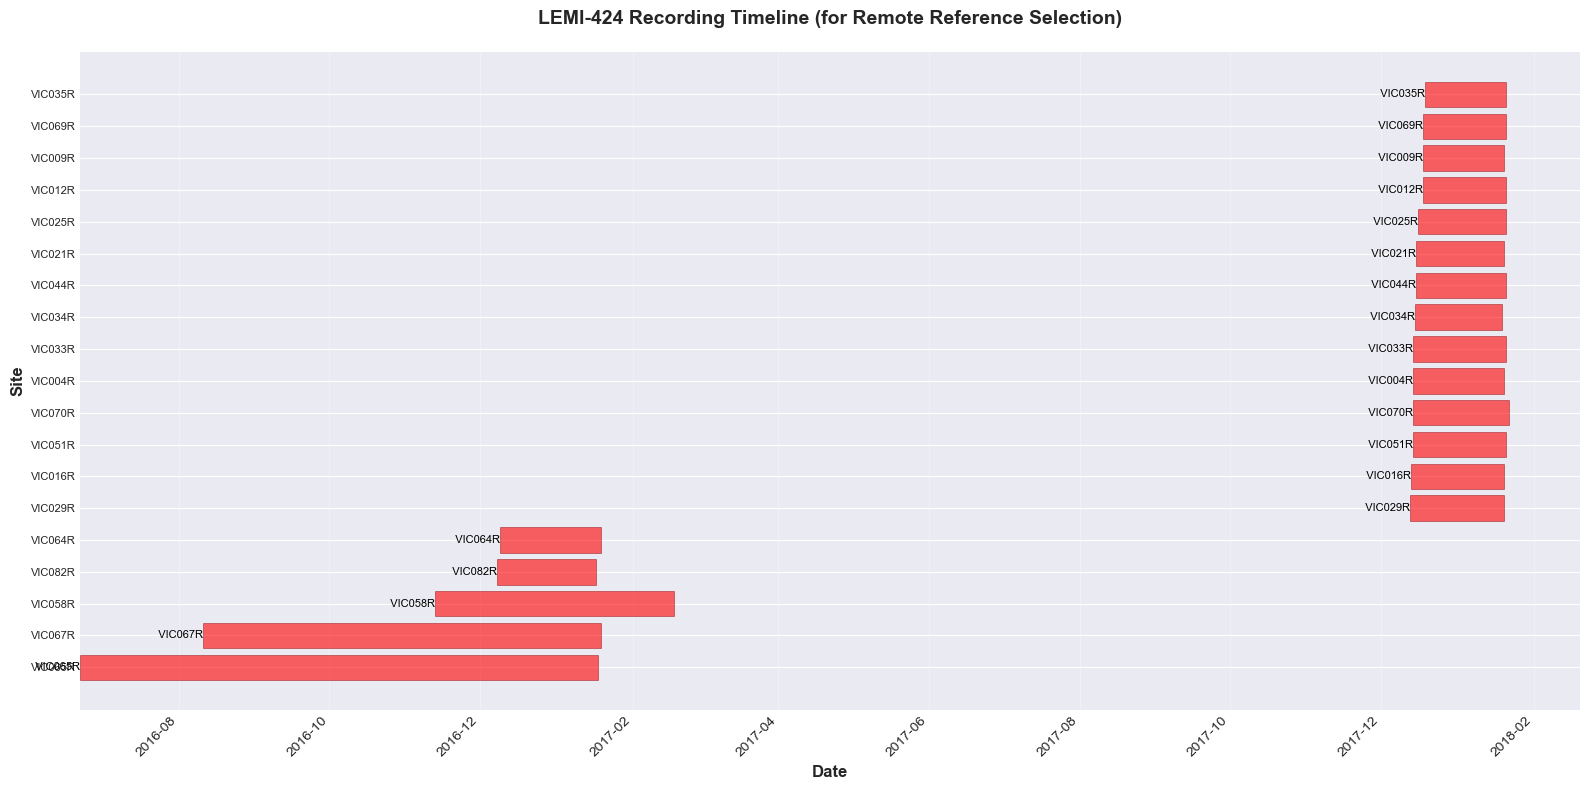

*Figure 3. LEMI-424 recording timeline showing 19 sites sorted by start date. These sites recorded 2016-2017, separate from EDL deployments. Note VIC065R and VIC067R have significantly longer durations (~210 and ~161 days) suitable for use as remote reference stations.*

In [6]:
# LEMI-424 Recording Timeline
lemi_data = df_meta[df_meta['instrument'] == 'LEMI-424'].copy()
lemi_data = lemi_data.sort_values('start_time')

fig, ax = plt.subplots(figsize=(16, 8))

for idx, (_, row) in enumerate(lemi_data.iterrows()):
    ax.barh(idx, 
            (row['end_time'] - row['start_time']).total_seconds() / 86400,
            left=row['start_time'], 
            height=0.8, 
            color='red', 
            alpha=0.6,
            edgecolor='darkred',
            linewidth=0.5)
    
    # Add site name label
    ax.text(row['start_time'], idx, f"  {row['station_id']}", 
            va='center', ha='right', fontsize=8, color='black')

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Site', fontsize=12, fontweight='bold')
ax.set_title('LEMI-424 Recording Timeline (for Remote Reference Selection)', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='x')
ax.set_yticks(range(len(lemi_data)))
ax.set_yticklabels(lemi_data['station_id'].values, fontsize=8)

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
fig.savefig(DataPaths.FIGURES_DIR / 'lemi_recording_timeline.png', dpi=300, bbox_inches='tight')
plt.show()

caption(f"Figure 3. LEMI-424 recording timeline showing {len(lemi_data)} sites sorted by start date. "
        f"These sites recorded 2016-2017, separate from EDL deployments. "
        f"Note VIC065R and VIC067R have significantly longer durations (~210 and ~161 days) "
        f"suitable for use as remote reference stations.")

## 4. Statistical Analysis (First Hour)

Load first hour from each site and calculate statistics for QA/QC.

In [7]:
# Function to get statistics from first hour
def get_site_statistics(mth5_file, duration_hours=1):
    """Calculate statistics from first N hours of recording."""
    try:
        df = read_station(mth5_file, channels='magnetic', verbose=False)
        
        # Get first N hours
        sample_rate = len(df) / ((df.index[-1] - df.index[0]).total_seconds() / 3600)
        n_samples = int(duration_hours * 3600 * sample_rate)
        df_sample = df.iloc[:n_samples]
        
        # Calculate statistics
        stats = {
            'bx_mean': df_sample['BX'].mean(),
            'by_mean': df_sample['BY'].mean(),
            'bz_mean': df_sample['BZ'].mean(),
            'bx_std': df_sample['BX'].std(),
            'by_std': df_sample['BY'].std(),
            'bz_std': df_sample['BZ'].std(),
            'n_samples': len(df_sample)
        }
        
        # Derived quantities
        stats['h_field'] = np.sqrt(stats['bx_mean']**2 + stats['by_mean']**2)
        stats['total_field'] = np.sqrt(stats['bx_mean']**2 + stats['by_mean']**2 + stats['bz_mean']**2)
        
        return stats
        
    except Exception as e:
        print(f"Error loading {Path(mth5_file).stem}: {e}")
        return None

print("Loading first hour from all sites for statistical analysis...")
print("This may take a few minutes...\n")

Loading first hour from all sites for statistical analysis...
This may take a few minutes...



In [8]:
# Calculate statistics for all sites
stats_list = []

for idx, row in df_meta.iterrows():
    station_id = row['station_id']
    mth5_file = Path(row['mth5_file'])
    
    print(f"[{idx+1}/{len(df_meta)}] {station_id}...", end=' ')
    
    stats = get_site_statistics(mth5_file)
    
    if stats:
        stats['station_id'] = station_id
        stats['instrument'] = row['instrument']
        stats_list.append(stats)
        print("✓")
    else:
        print("✗")

df_stats = pd.DataFrame(stats_list)

print(f"\n✓ Successfully calculated statistics for {len(df_stats)}/{len(df_meta)} sites")

[1/100] VIC001... ✓
[2/100] VIC002... ✓
[3/100] VIC003... ✓
[4/100] VIC004R... ✓
[5/100] VIC005... ✓
[6/100] VIC006... ✓
[7/100] VIC007... ✓
[8/100] VIC008... ✓
[9/100] VIC009R... ✓
[10/100] VIC010... ✓
[11/100] VIC011... ✓
[12/100] VIC012R... ✓
[13/100] VIC013... ✓
[14/100] VIC014... ✓
[15/100] VIC015... ✓
[16/100] VIC016R... ✓
[17/100] VIC017... ✓
[18/100] VIC018... ✓
[19/100] VIC021R... ✓
[20/100] VIC022... ✓
[21/100] VIC023... ✓
[22/100] VIC024... ✓
[23/100] VIC025R... ✓
[24/100] VIC026... ✓
[25/100] VIC027... ✓
[26/100] VIC028... ✓
[27/100] VIC029R... ✓
[28/100] VIC030... ✓
[29/100] VIC031... ✓
[30/100] VIC032... ✓
[31/100] VIC033R... ✓
[32/100] VIC034R... ✓
[33/100] VIC035R... ✓
[34/100] VIC036... ✓
[35/100] VIC037... ✓
[36/100] VIC038... ✓
[37/100] VIC039... ✓
[38/100] VIC040... ✓
[39/100] VIC041... ✓
[40/100] VIC042... ✓
[41/100] VIC043... ✓
[42/100] VIC044R... ✓
[43/100] VIC045... ✓
[44/100] VIC046... ✓
[45/100] VIC047... ✓
[46/100] VIC048... ✓
[47/100] VIC049... ✓
[48/100] VI

In [9]:
# Merge statistics with metadata
df_full = df_meta.merge(df_stats, on=['station_id', 'instrument'], how='left')

# Save combined data
output_file = DataPaths.PROCESSED_DATA_DIR / 'qaqc' / 'site_statistics.csv'
output_file.parent.mkdir(parents=True, exist_ok=True)
df_full.to_csv(output_file, index=False)

print(f"Saved statistics to: {output_file}")
print(f"\nPreview:")
df_full[['station_id', 'instrument', 'bx_mean', 'by_mean', 'bz_mean', 
         'h_field', 'total_field']].head(10)

Saved statistics to: d:\BK_AusLAMP_GA\notebooks\..\data\processed\qaqc\site_statistics.csv

Preview:


,station_id,instrument,bx_mean,by_mean,bz_mean,h_field,total_field
0,VIC001,EDL,22063.30,-1573.10,-55299.21,22119.31,59558.93
1,VIC002,EDL,20526.29,3387.67,-53194.11,20803.96,57117.59
2,VIC003,EDL,20960.36,-1020.19,-56508.04,20985.17,60278.82
3,VIC004R,LEMI-424,21074.72,1.09,-56768.98,21074.72,60554.61
4,VIC005,EDL,22342.55,1930.25,-55723.63,22425.78,60066.95
5,VIC006,EDL,22367.89,2639.17,-55580.68,22523.05,59970.82
6,VIC007,EDL,19405.80,-2587.24,-56494.99,19577.51,59791.00
7,VIC008,EDL,20567.72,1049.81,-56095.32,20594.49,59756.33
8,VIC009R,LEMI-424,21492.89,192.33,-56265.03,21493.75,60230.68
9,VIC010,EDL,-23404.71,-503.24,-55244.18,23410.12,59999.61


## 5. Statistical Plots

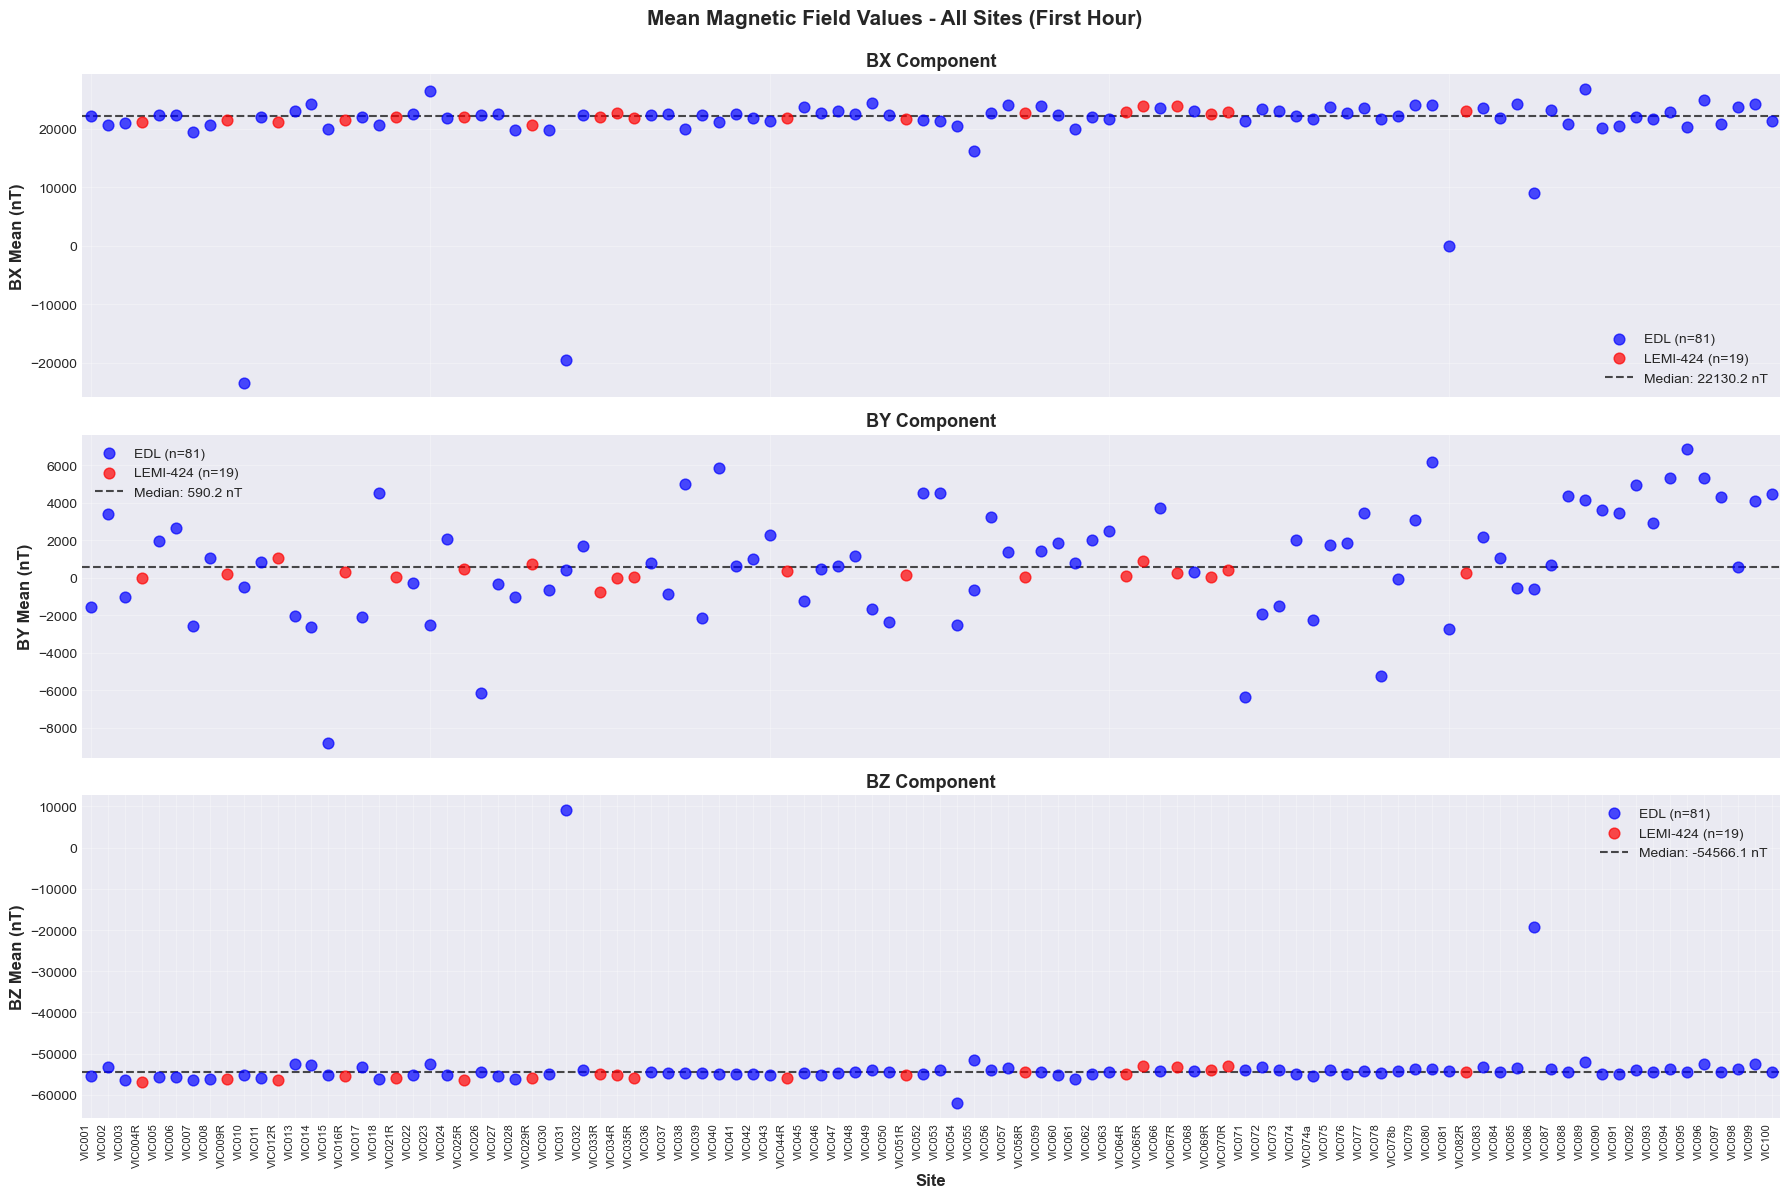

*Figure 4. Mean magnetic field values for all 100 sites (first hour of recording). Blue: EDL. Red: LEMI-424. Black dashed line shows overall median.*

In [10]:
# Plot mean magnetic field values
fig, axes = plt.subplots(3, 1, figsize=(18, 12))

channels = ['bx', 'by', 'bz']
colors = {'EDL': 'blue', 'LEMI-424': 'red'}

sites_with_data = df_full.dropna(subset=['bx_mean']).copy()
sites_with_data = sites_with_data.sort_values('station_id')

for i, ch in enumerate(channels):
    ax = axes[i]
    
    # Plot by instrument
    for instrument in ['EDL', 'LEMI-424']:
        subset = sites_with_data[sites_with_data['instrument'] == instrument]
        
        if len(subset) > 0:
            mask = sites_with_data['instrument'] == instrument
            x_instrument = [i for i, m in enumerate(mask) if m]
            y = subset[f'{ch}_mean'].values
            ax.scatter(x_instrument, y, c=colors[instrument], alpha=0.7, s=60, 
                      label=f'{instrument} (n={len(subset)})', zorder=3)
    
    # Add median line
    median_val = sites_with_data[f'{ch}_mean'].median()
    ax.axhline(median_val, color='black', linestyle='--', linewidth=1.5, alpha=0.7,
              label=f'Median: {median_val:.1f} nT', zorder=2)
    
    ax.set_ylabel(f'{ch.upper()} Mean (nT)', fontsize=12, fontweight='bold')
    ax.set_title(f'{ch.upper()} Component', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.3, zorder=1)
    ax.set_xlim(-0.5, len(sites_with_data) - 0.5)
    
    if i == len(channels) - 1:  # Bottom plot
        ax.set_xlabel('Site', fontsize=12, fontweight='bold')
        tick_positions = range(len(sites_with_data))
        tick_labels = sites_with_data['station_id'].values
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=90, fontsize=8, ha='right')
    else:
        ax.set_xticklabels([])

plt.suptitle('Mean Magnetic Field Values - All Sites (First Hour)', 
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
fig.savefig(DataPaths.FIGURES_DIR / 'qaqc' / 'mean_field_values.png', dpi=300, bbox_inches='tight')
plt.show()

caption(f"Figure 4. Mean magnetic field values for all {len(sites_with_data)} sites (first hour of recording). "
        f"Blue: EDL. Red: LEMI-424. Black dashed line shows overall median.")

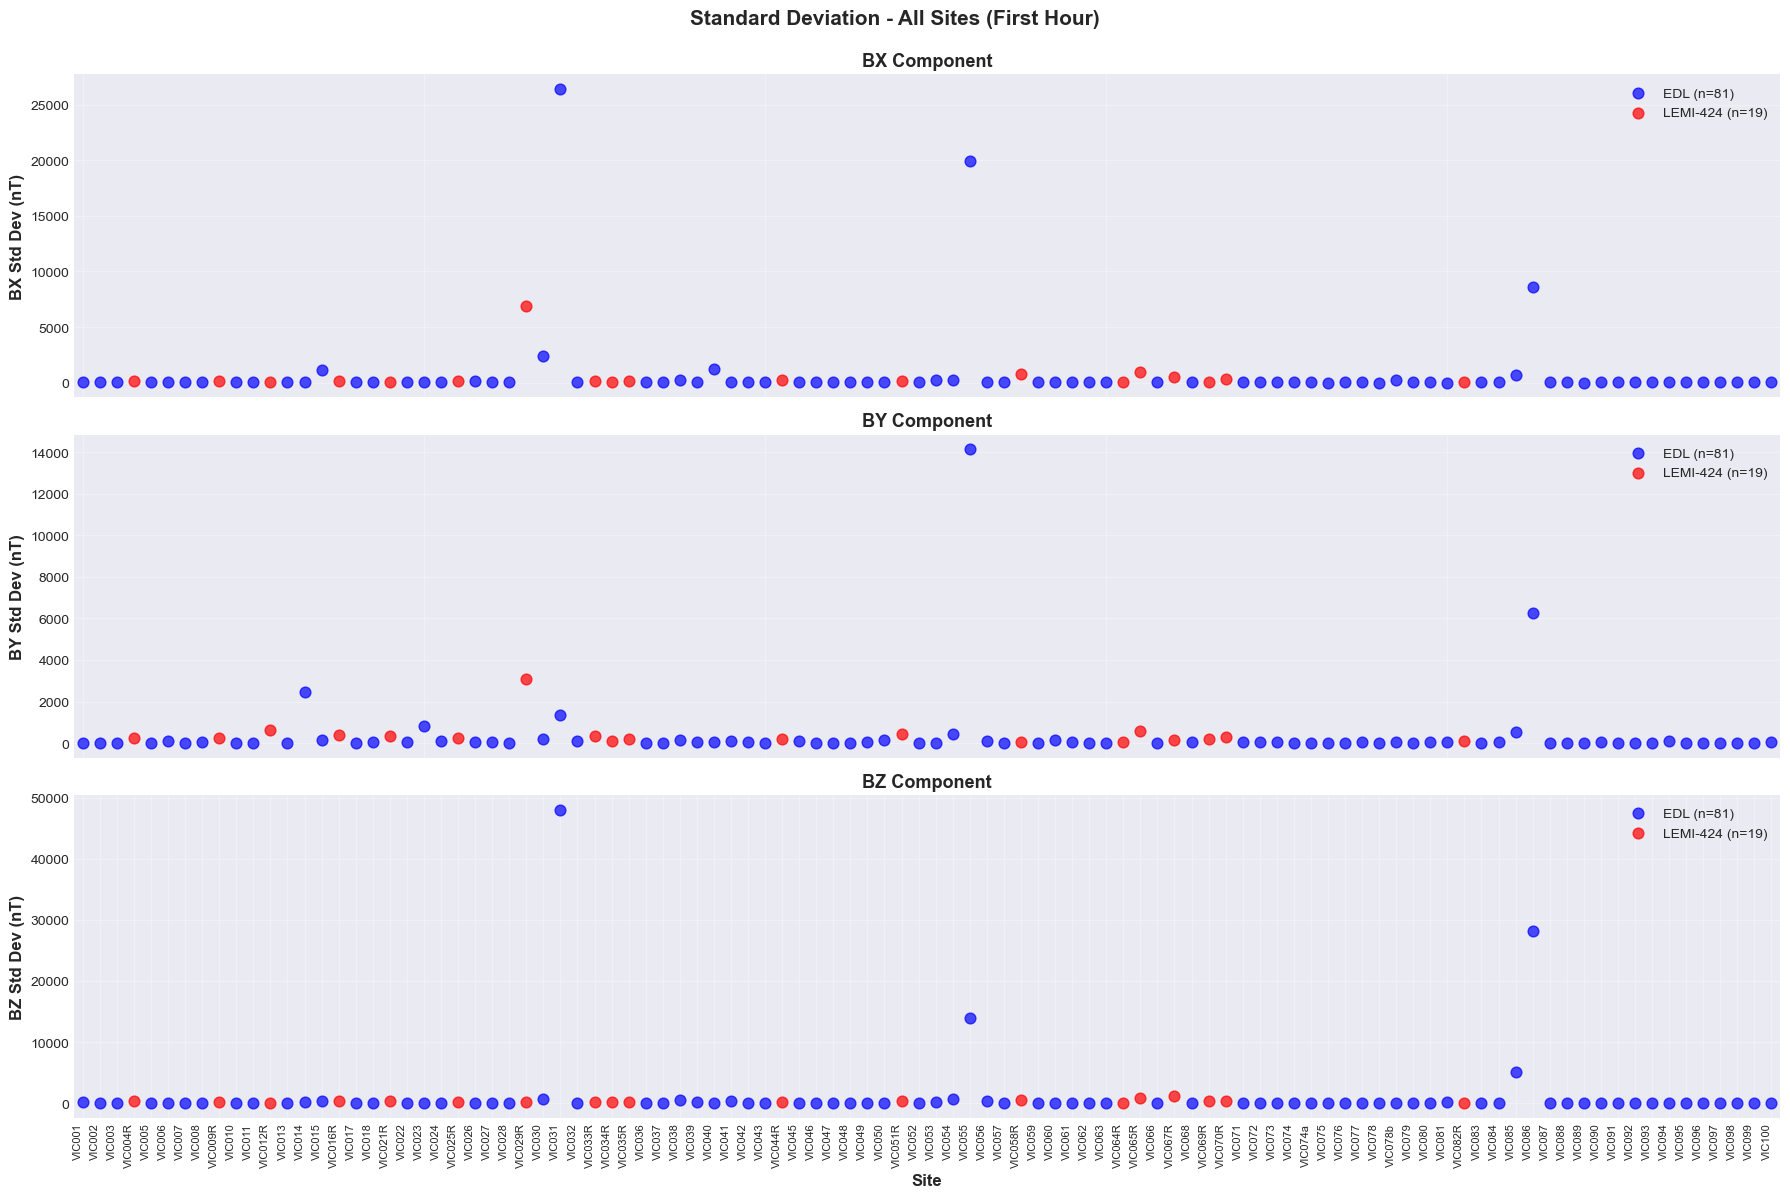

*Figure 5. Standard deviation of magnetic field components. Shows natural field variations and instrument noise levels.*

In [11]:
# Plot standard deviations
fig, axes = plt.subplots(3, 1, figsize=(18, 12))

for i, ch in enumerate(channels):
    ax = axes[i]
    
    for instrument in ['EDL', 'LEMI-424']:
        subset = sites_with_data[sites_with_data['instrument'] == instrument]
        
        if len(subset) > 0:
            mask = sites_with_data['instrument'] == instrument
            x_instrument = [i for i, m in enumerate(mask) if m]
            y = subset[f'{ch}_std'].values
            ax.scatter(x_instrument, y, c=colors[instrument], alpha=0.7, s=60,
                      label=f'{instrument} (n={len(subset)})', zorder=3)
    
    ax.set_ylabel(f'{ch.upper()} Std Dev (nT)', fontsize=12, fontweight='bold')
    ax.set_title(f'{ch.upper()} Component', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.3, zorder=1)
    ax.set_xlim(-0.5, len(sites_with_data) - 0.5)
    
    if i == len(channels) - 1:
        ax.set_xlabel('Site', fontsize=12, fontweight='bold')
        tick_positions = range(len(sites_with_data))
        tick_labels = sites_with_data['station_id'].values
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=90, fontsize=8, ha='right')
    else:
        ax.set_xticklabels([])

plt.suptitle('Standard Deviation - All Sites (First Hour)', 
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
fig.savefig(DataPaths.FIGURES_DIR / 'qaqc' / 'std_field_values.png', dpi=300, bbox_inches='tight')
plt.show()

caption(f"Figure 5. Standard deviation of magnetic field components. "
        f"Shows natural field variations and instrument noise levels.")

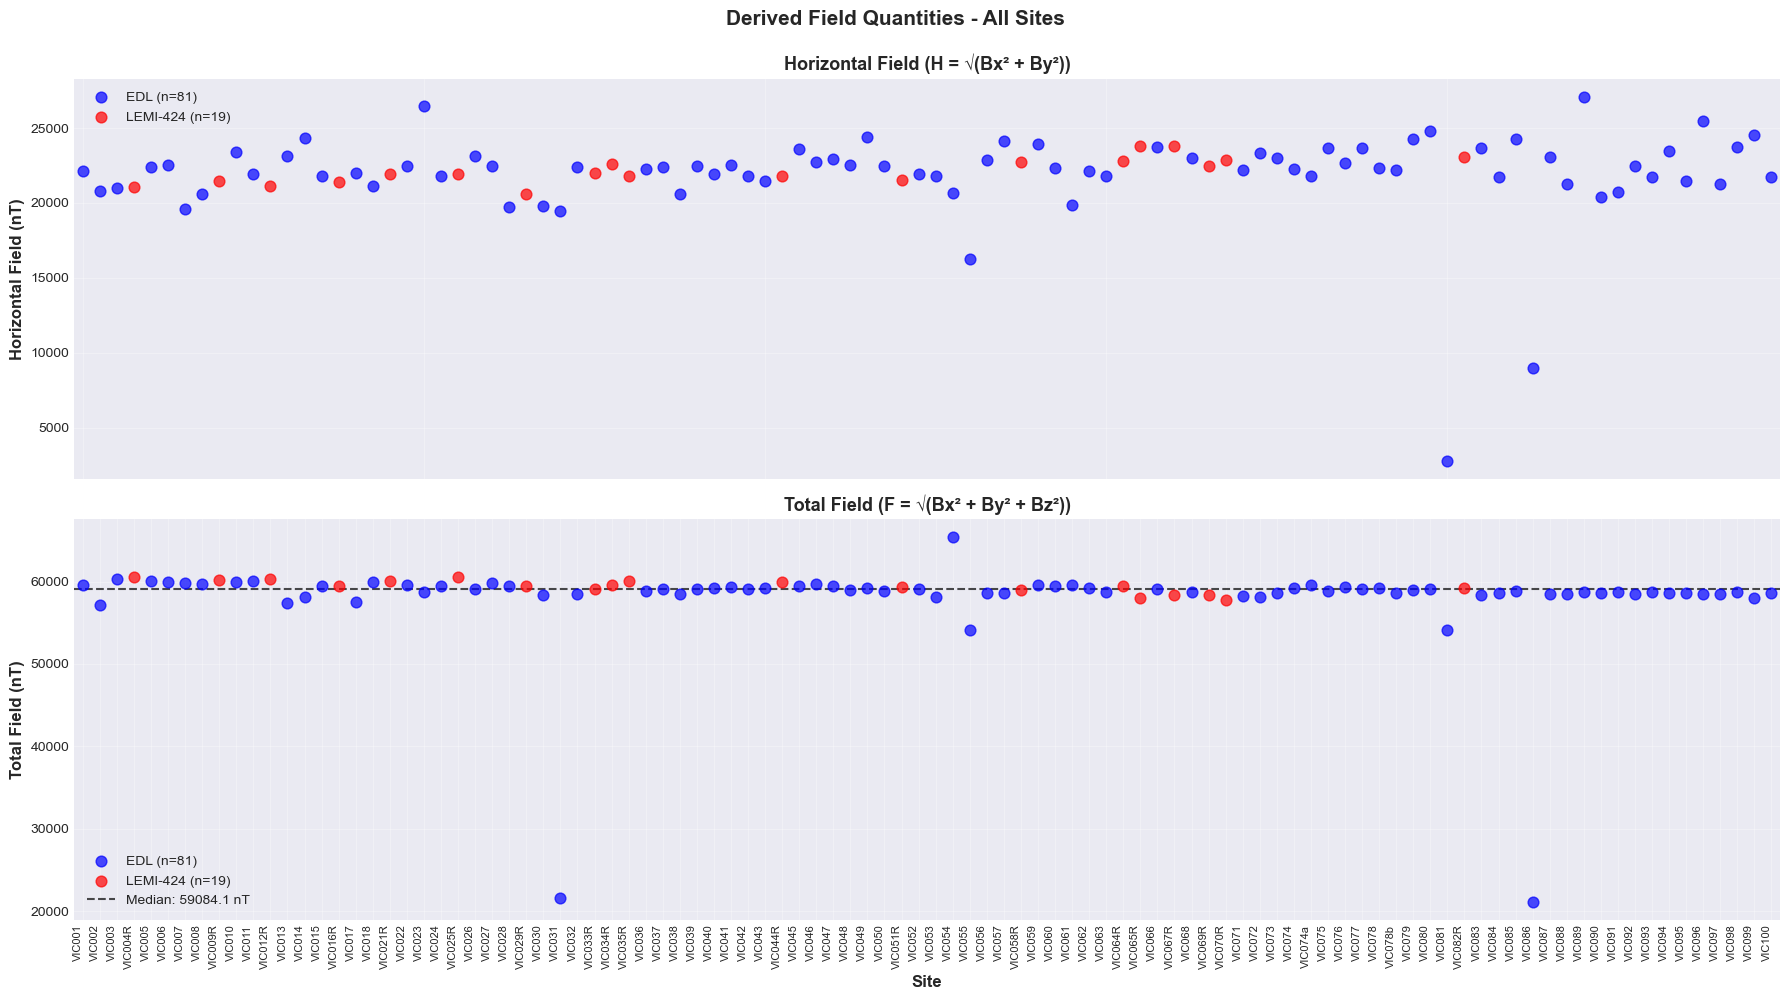

*Figure 6. Horizontal and total field strength for all sites.*

In [12]:
# Plot horizontal and total field
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# Horizontal field
ax = axes[0]
for instrument in ['EDL', 'LEMI-424']:
    subset = sites_with_data[sites_with_data['instrument'] == instrument]
    
    if len(subset) > 0:
        mask = sites_with_data['instrument'] == instrument
        x_instrument = [i for i, m in enumerate(mask) if m]
        y = subset['h_field'].values
        ax.scatter(x_instrument, y, c=colors[instrument], alpha=0.7, s=60,
                  label=f'{instrument} (n={len(subset)})', zorder=3)

ax.set_ylabel('Horizontal Field (nT)', fontsize=12, fontweight='bold')
ax.set_title('Horizontal Field (H = √(Bx² + By²))', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3, zorder=1)
ax.set_xticklabels([])
ax.set_xlim(-0.5, len(sites_with_data) - 0.5)

# Total field
ax = axes[1]
for instrument in ['EDL', 'LEMI-424']:
    subset = sites_with_data[sites_with_data['instrument'] == instrument]
    
    if len(subset) > 0:
        mask = sites_with_data['instrument'] == instrument
        x_instrument = [i for i, m in enumerate(mask) if m]
        y = subset['total_field'].values
        ax.scatter(x_instrument, y, c=colors[instrument], alpha=0.7, s=60,
                  label=f'{instrument} (n={len(subset)})', zorder=3)

median_total = sites_with_data['total_field'].median()
ax.axhline(median_total, color='black', linestyle='--', linewidth=1.5, alpha=0.7,
          label=f'Median: {median_total:.1f} nT', zorder=2)

ax.set_ylabel('Total Field (nT)', fontsize=12, fontweight='bold')
ax.set_xlabel('Site', fontsize=12, fontweight='bold')
ax.set_title('Total Field (F = √(Bx² + By² + Bz²))', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3, zorder=1)
ax.set_xlim(-0.5, len(sites_with_data) - 0.5)

tick_positions = range(len(sites_with_data))
tick_labels = sites_with_data['station_id'].values
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=90, fontsize=8, ha='right')

plt.suptitle('Derived Field Quantities - All Sites', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
fig.savefig(DataPaths.FIGURES_DIR / 'qaqc' / 'derived_field_quantities.png', dpi=300, bbox_inches='tight')
plt.show()

caption(f"Figure 6. Horizontal and total field strength for all sites.")

## 6. AGRF25 Model Comparison

Compare measured fields to Australian Geomagnetic Reference Field model (future notebook).

In [13]:
print("AGRF25 comparison will be implemented in notebook 03_agrf_comparison.ipynb")
print("\nThis will include:")
print("  - AGRF25 calculation at each site")
print("  - Residual analysis (measured - model)")
print("  - Identification of secular variation")
print("  - Detection of crustal magnetic anomalies")

AGRF25 comparison will be implemented in notebook 03_agrf_comparison.ipynb

This will include:
  - AGRF25 calculation at each site
  - Residual analysis (measured - model)
  - Identification of secular variation
  - Detection of crustal magnetic anomalies


## 7. QA/QC Summary

In [14]:
# Identify potential issues
issues = []

# Check for short recordings
short_threshold = 15  # days
short_recordings = df_full[df_full['duration_days'] < short_threshold]
if len(short_recordings) > 0:
    issues.append(f"⚠️  {len(short_recordings)} sites with duration < {short_threshold} days")
    for _, row in short_recordings.iterrows():
        issues.append(f"    - {row['station_id']}: {row['duration_days']:.1f} days")

# Check for missing statistics (failed loads)
missing_stats = df_full[df_full['bx_mean'].isna()]
if len(missing_stats) > 0:
    issues.append(f"⚠️  {len(missing_stats)} sites failed to load for statistics")
    for _, row in missing_stats.iterrows():
        issues.append(f"    - {row['station_id']}")

# Check for high noise (large std)
noise_threshold = 50  # nT
high_noise = df_full[(df_full['bx_std'] > noise_threshold) | 
                     (df_full['by_std'] > noise_threshold) | 
                     (df_full['bz_std'] > noise_threshold)]
if len(high_noise) > 0:
    issues.append(f"⚠️  {len(high_noise)} sites with high noise (std > {noise_threshold} nT)")
    for _, row in high_noise.iterrows():
        issues.append(f"    - {row['station_id']}: BX={row['bx_std']:.1f}, BY={row['by_std']:.1f}, BZ={row['bz_std']:.1f} nT")

# Print summary
print("QA/QC SUMMARY")
print("=" * 80)

if len(issues) == 0:
    print("✓ All sites passed QA/QC checks")
else:
    print(f"Found {len(issues)} potential issues:\n")
    for issue in issues:
        print(issue)

print("\n" + "=" * 80)
print(f"Total sites analyzed: {len(df_full)}")
print(f"Sites with complete statistics: {df_full['bx_mean'].notna().sum()}")
print(f"\nRecommendation: {df_full['bx_mean'].notna().sum() - len(high_noise) - len(short_recordings)} sites are suitable for MT processing")

QA/QC SUMMARY
Found 63 potential issues:

⚠️  9 sites with duration < 15 days
    - VIC031: 13.1 days
    - VIC043: 14.6 days
    - VIC060: 14.2 days
    - VIC074: 9.3 days
    - VIC075: 14.1 days
    - VIC076: 14.2 days
    - VIC077: 13.6 days
    - VIC088: 14.6 days
    - VIC090: 14.6 days
⚠️  52 sites with high noise (std > 50 nT)
    - VIC001: BX=19.8, BY=20.8, BZ=141.5 nT
    - VIC004R: BX=110.6, BY=220.1, BZ=304.8 nT
    - VIC006: BX=25.1, BY=99.4, BZ=22.2 nT
    - VIC009R: BX=159.4, BY=222.9, BZ=169.2 nT
    - VIC012R: BX=80.2, BY=622.8, BZ=38.2 nT
    - VIC014: BX=57.3, BY=2470.3, BZ=130.5 nT
    - VIC015: BX=1100.6, BY=148.3, BZ=417.7 nT
    - VIC016R: BX=139.8, BY=399.8, BZ=281.8 nT
    - VIC017: BX=57.0, BY=24.3, BZ=15.0 nT
    - VIC018: BX=50.4, BY=39.5, BZ=31.8 nT
    - VIC021R: BX=94.8, BY=358.6, BZ=356.7 nT
    - VIC022: BX=19.1, BY=58.0, BZ=10.3 nT
    - VIC023: BX=29.3, BY=819.9, BZ=53.2 nT
    - VIC024: BX=71.1, BY=77.1, BZ=25.9 nT
    - VIC025R: BX=179.1, BY=265.9, B

## Summary

**Completed**:
- ✓ Loaded metadata for 100 sites (81 EDL + 19 LEMI-424)
- ✓ Created site location map
- ✓ Generated recording timelines for remote reference selection
- ✓ Calculated statistical metrics for all sites
- ✓ Generated QA/QC plots and summary

**Next Steps**:
1. AGRF25 model comparison (notebook 03)
2. Select representative sites for MT processing
3. Identify optimal remote reference pairs
4. Begin impedance tensor estimation